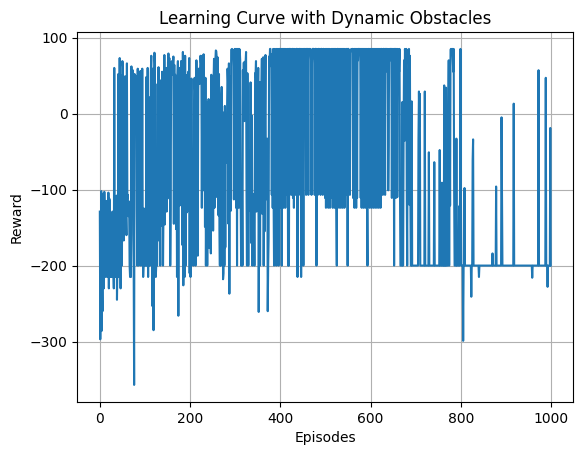

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [4,4, 1,0],
            [6,2, -1,1],
            [2,7, 0,-1]
        ]

    def reset(self):
        self.robot = (0,0)
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            if obs[0] <=0 or obs[0] >= self.size-1:
                obs[2] *= -1
            if obs[1] <=0 or obs[1] >= self.size-1:
                obs[3] *= -1

    def predict_obstacles(self):
        return [(obs[0] + obs[2], obs[1] + obs[3]) for obs in self.obstacles]

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward
        if action == 1: y = max(0, y-1)             # left
        if action == 2: y = min(self.size-1, y+1)   # right

        self.robot = (x,y)

        # Move dynamic obstacles
        self.move_obstacles()
        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        for ox, oy, vx, vy in self.obstacles:
            if (x,y) == (ox,oy):
                return self.get_state(), -100, True
            if (x,y) in pred:
                reward -= 5  # near collision

        if (x,y) == self.goal:
            return self.get_state(), 100, True

        return self.get_state(), reward, False

    def get_state(self):
        return (*self.robot,)


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0)

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 1000
eps = 0.2
alpha = 0.1
gamma = 0.9

rewards = []

for ep in range(episodes):
    state = env.reset()
    total = 0

    for t in range(200):
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        best_next = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha*(reward + gamma*best_next - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward

        if done:
            break

    rewards.append(total)
    eps *= 0.995

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.grid(True)
plt.show()